### **Comparando Modelos**

In [1]:
# Importando Bibliotecas
import os
import pickle

from src.utils import set_seed
from src.evalutation.model_comparator import ModelComparator

set_seed(42)

### **Selecionando Modelos a serem comparados**

In [4]:
# Escolhendo modelos single-stage para comparar:
list_models_single_stage = [r"data\model_weights\UNet_ImageNet\FocalMSELoss_1ep\1783093205",
                            r"data\model_weights\FullHRNet_ImageNet\MSELoss_200ep_32W\1791552534",
]

# Escolhendo modelos dois estágios para comparar:
list_models_two_stage = [
    (r"data\model_weights\GlobalStageWrapper\MSELoss_80ep\1790014927", r"data\model_weights\LocalStageWrapper\MSELoss_80ep\1790014928"),
]

In [5]:
# Coletando Configurações dos modelos single-stage:
dict_config = {}
for model in list_models_single_stage:
    with open(os.path.join(model,'config.pkl'), 'rb') as f:
        config_model = pickle.load(f)
        dict_config[model] = config_model

# Coletando Configurações dos modelos dois estágios:
for (stage1_dir, stage2_dir) in list_models_two_stage:
    with open(os.path.join(stage1_dir, 'config.pkl'), 'rb') as f:
        config_stage1 = pickle.load(f)
    with open(os.path.join(stage2_dir, 'config.pkl'), 'rb') as f:
        config_stage2 = pickle.load(f)
    # Chave = diretório do stage1; valor = tupla de configs
    dict_config[stage1_dir] = (config_stage1, config_stage2)


INICIANDO AVALIAÇÃO NO CONJUNTO DE TESTE
✓ Modelo carregado: data\model_weights\UNet_ImageNet\FocalMSELoss_1ep\1783093205\fold_1_best.pth
  Epoch: 0
  Val Loss: 0.0307

Avaliando 178 amostras do conjunto de teste...


Avaliando: 100%|██████████| 178/178 [00:07<00:00, 23.72it/s]



GERANDO VISUALIZAÇÕES


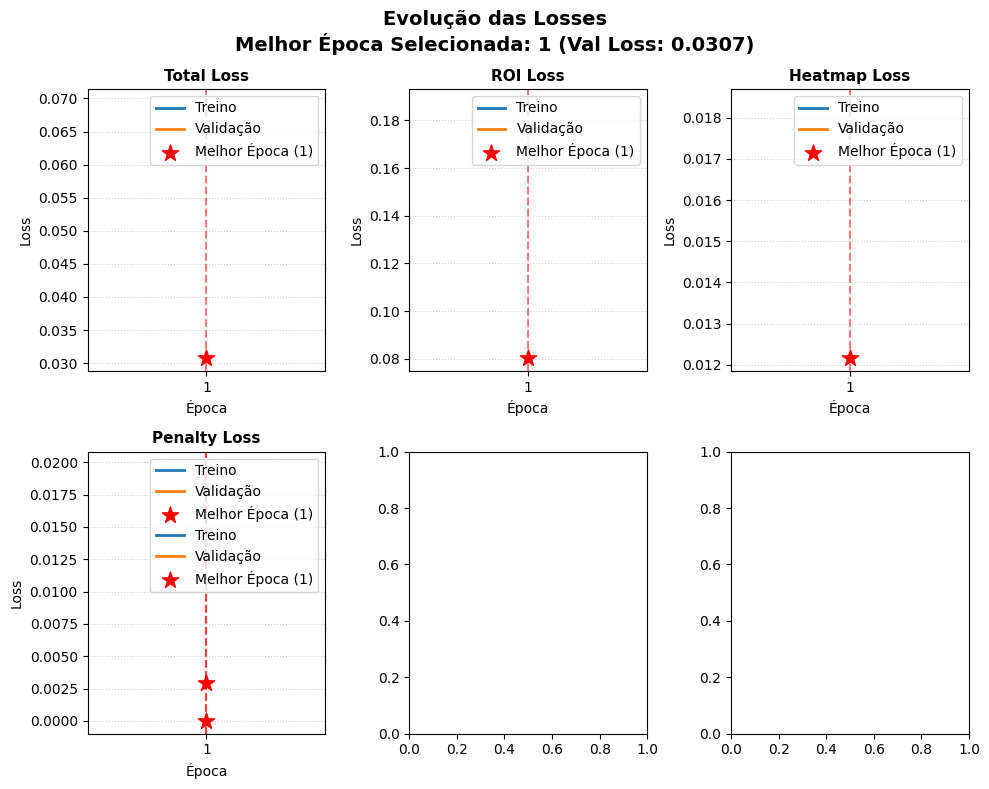

✓ Gráfico salvo: loss_distributions.png


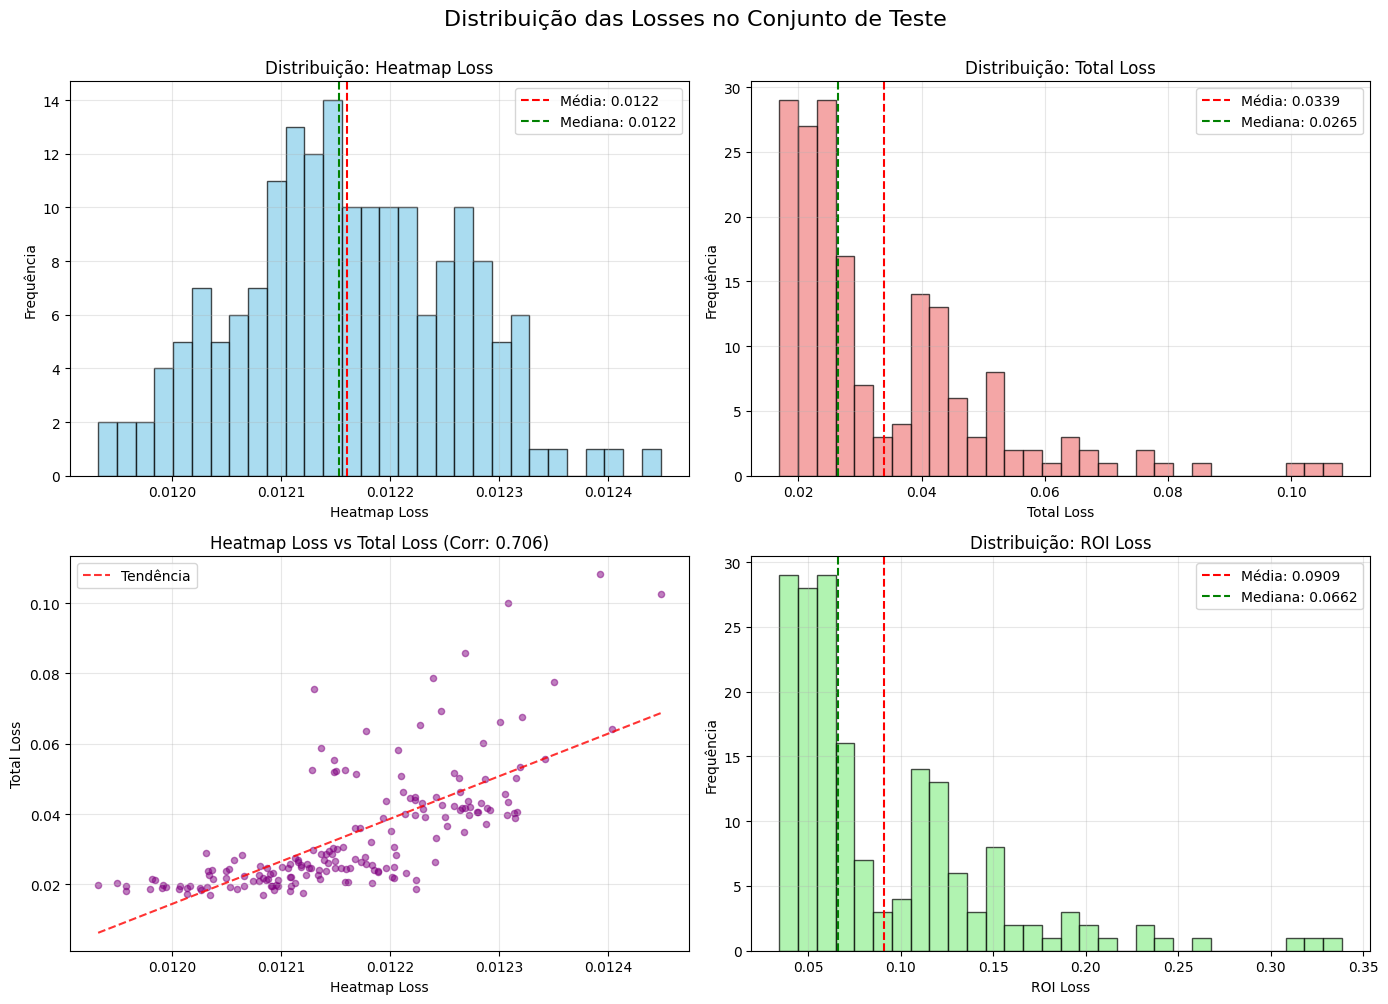

✓ Gráfico salvo: keypoint_analysis.png


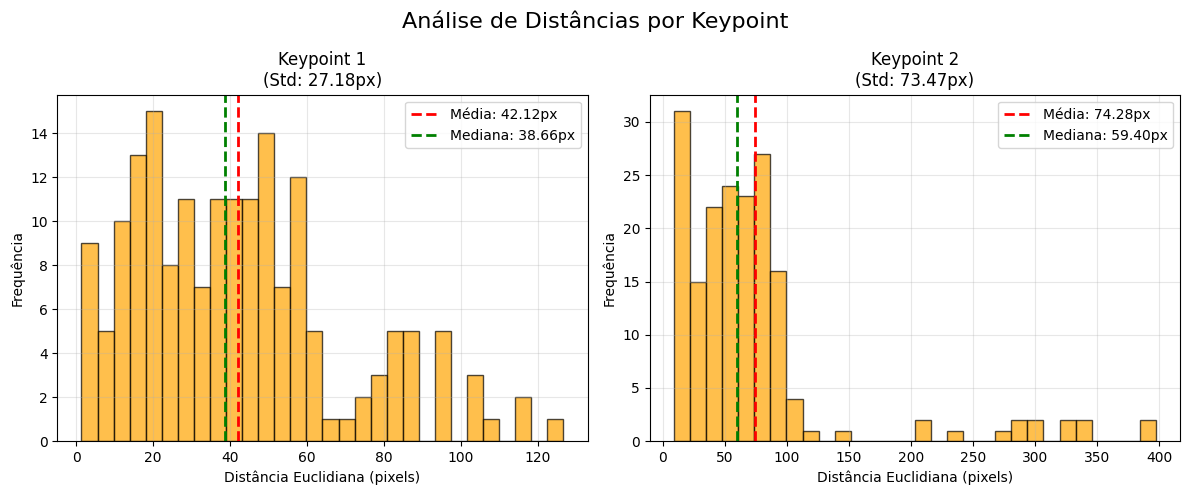


--- Visualizações para Keypoint 1 ---
✓ Figura salva: predictions_by_distance_keypoint1.png


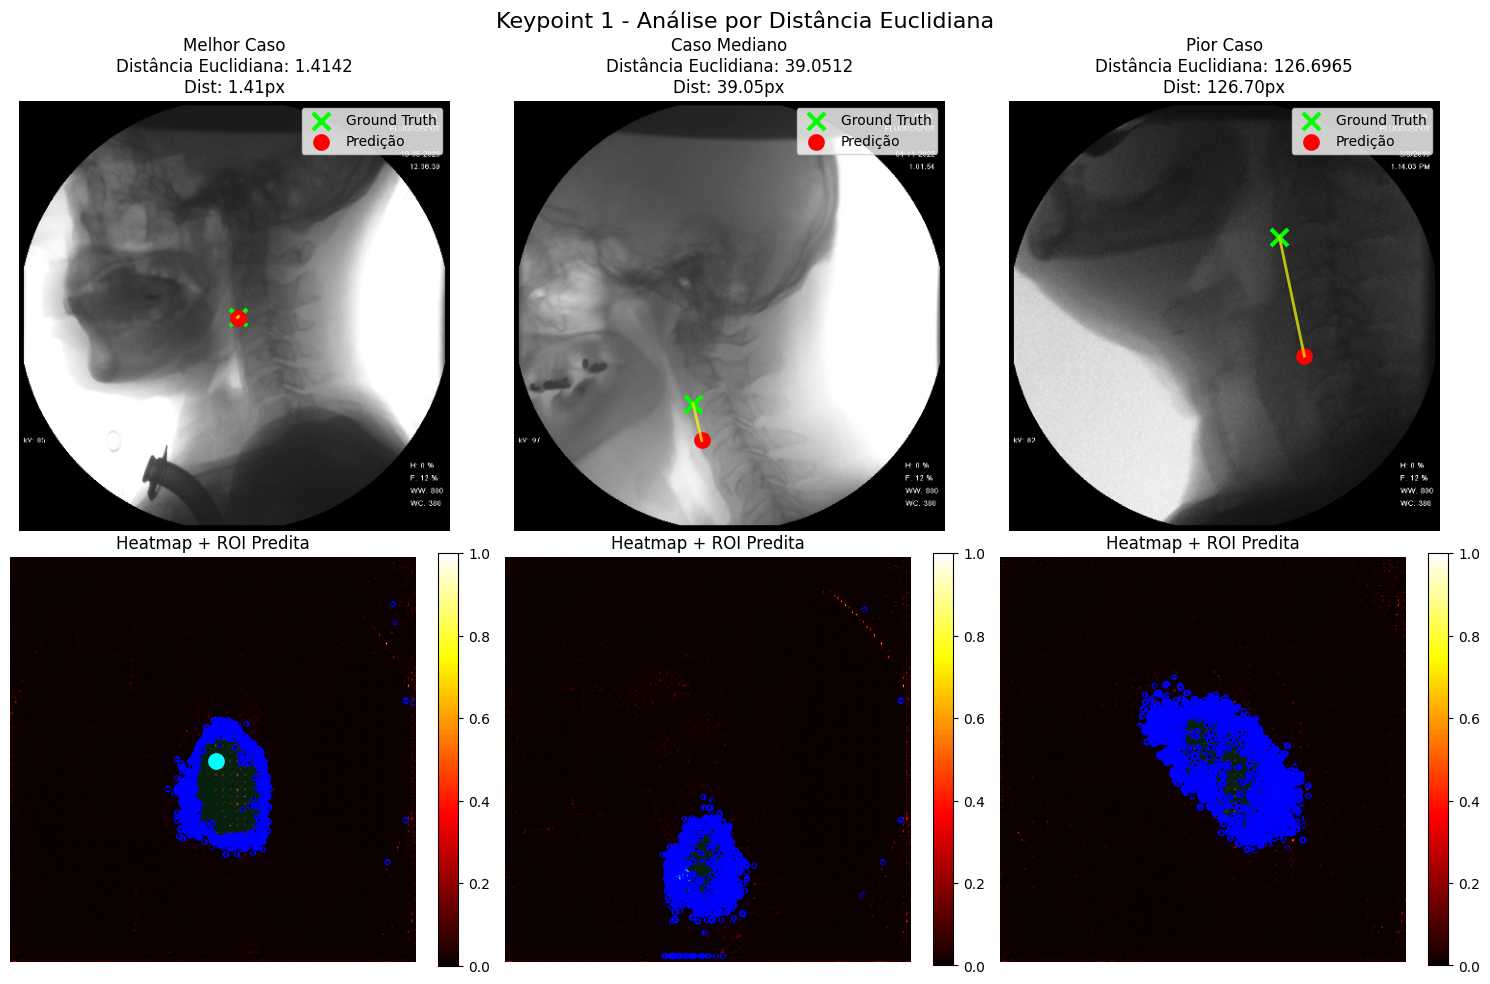


--- Visualizações para Keypoint 2 ---
✓ Figura salva: predictions_by_distance_keypoint2.png


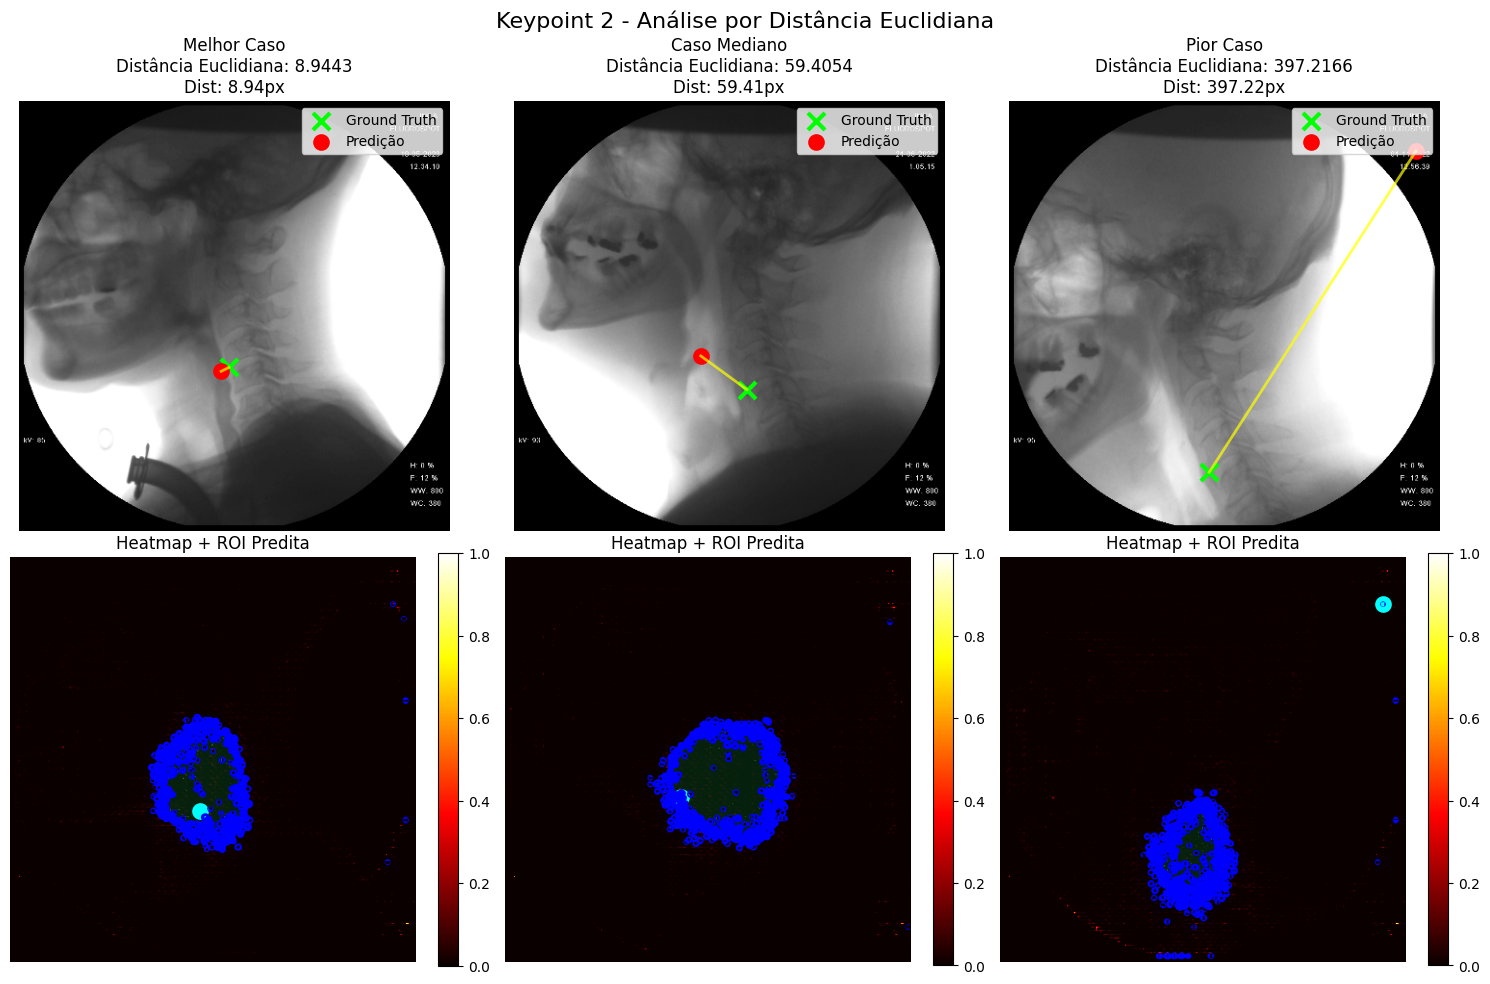


--- Visualizações para Keypoint 1 ---
✓ Figura salva: predictions_by_loss_keypoint1.png


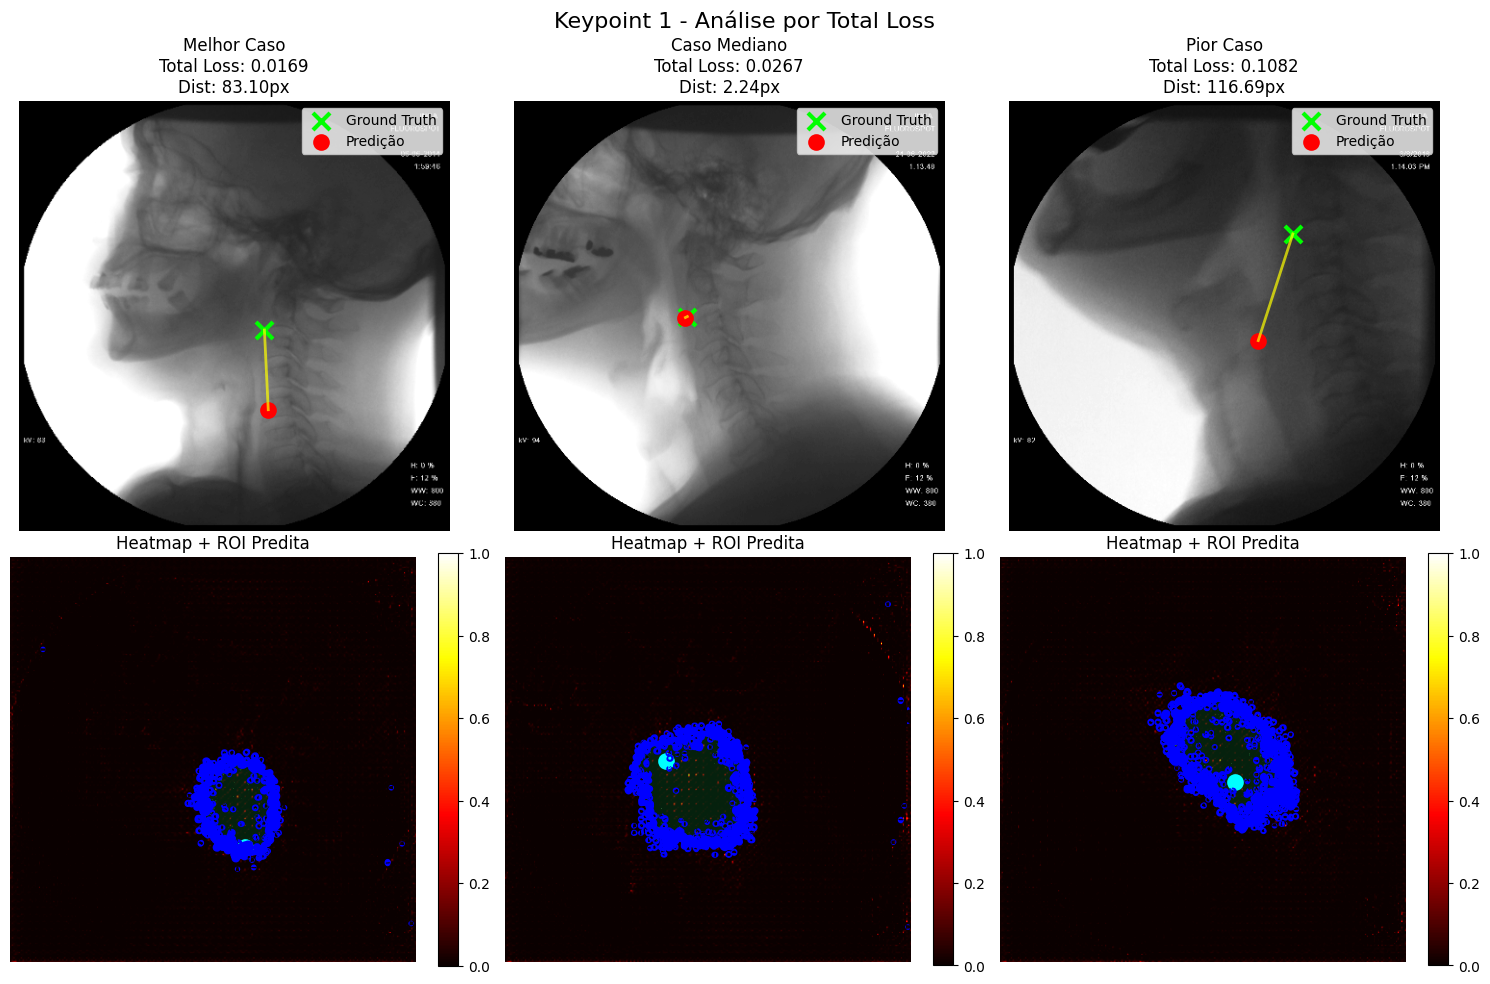


--- Visualizações para Keypoint 2 ---
✓ Figura salva: predictions_by_loss_keypoint2.png


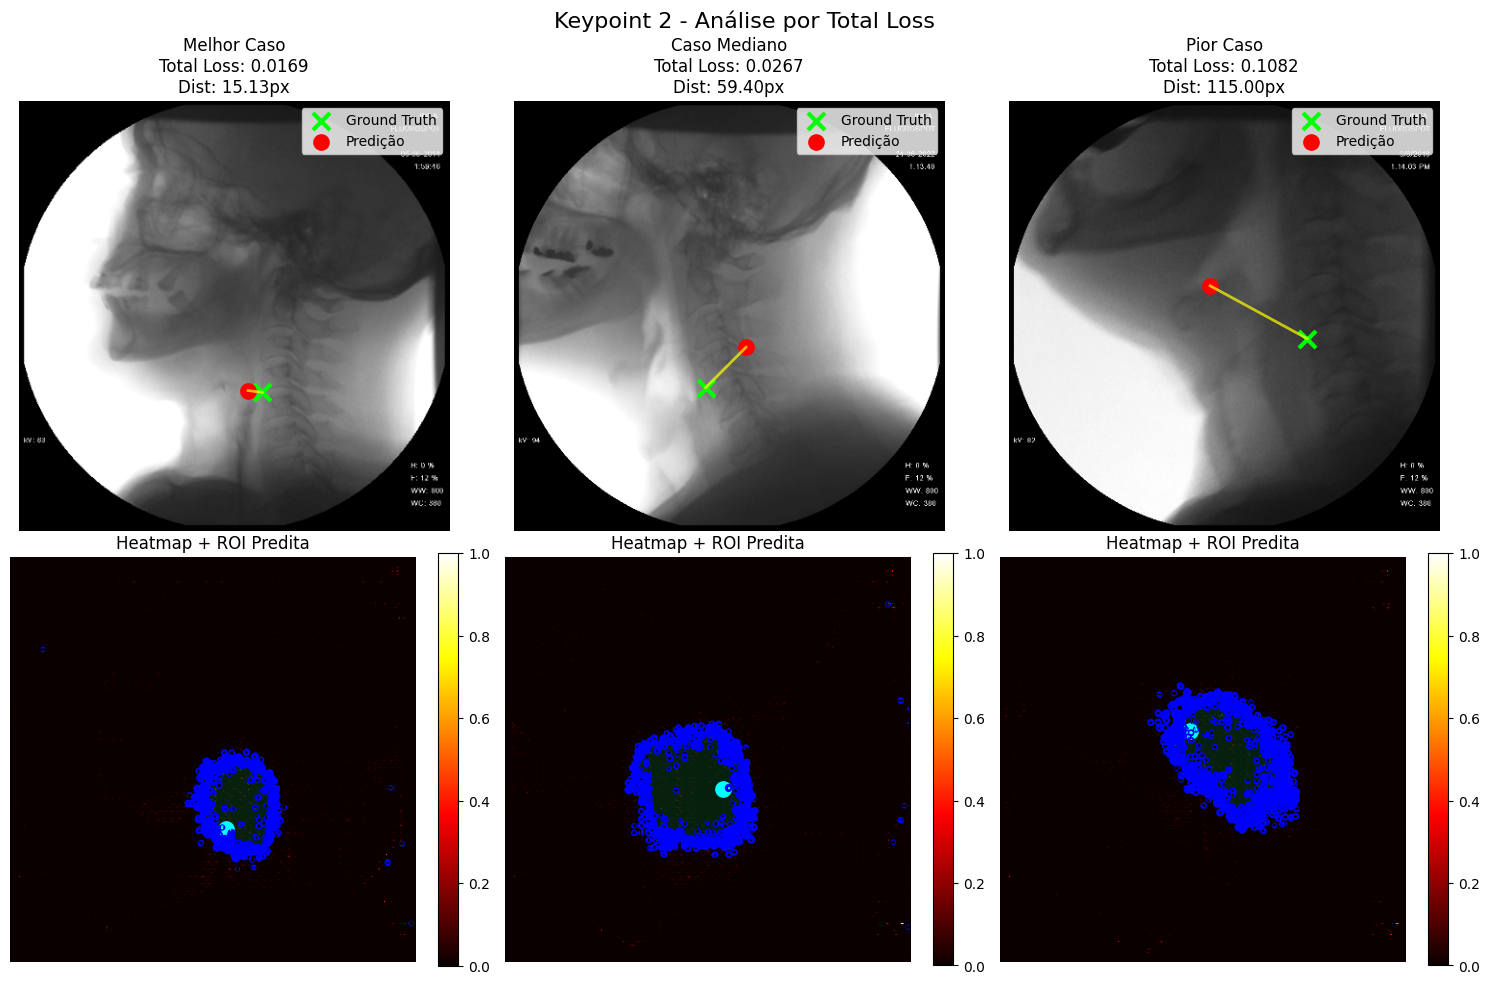

RELATÓRIO DE AVALIAÇÃO NO CONJUNTO DE TESTE

Número de amostras: 178

----------------------------------------------------------------------
LOSS TOTAL
----------------------------------------------------------------------
Média:    0.033906
Mediana:  0.026515
Std:      0.017070
Min:      0.016913
Max:      0.108222

----------------------------------------------------------------------
HEATMAP LOSS
----------------------------------------------------------------------
Média:    0.012161
Mediana:  0.012153
Std:      0.000100

----------------------------------------------------------------------
ROI LOSS
----------------------------------------------------------------------
Média:    0.090871
Mediana:  0.066170
Std:      0.056825

----------------------------------------------------------------------
KEYPOINT 1 - DISTÂNCIA EUCLIDIANA (pixels)
----------------------------------------------------------------------
Média:    42.12
Mediana:  38.66
Std:      27.18
Min:      1.41
Max:      1

Avaliando: 100%|██████████| 178/178 [00:04<00:00, 36.56it/s]



GERANDO VISUALIZAÇÕES


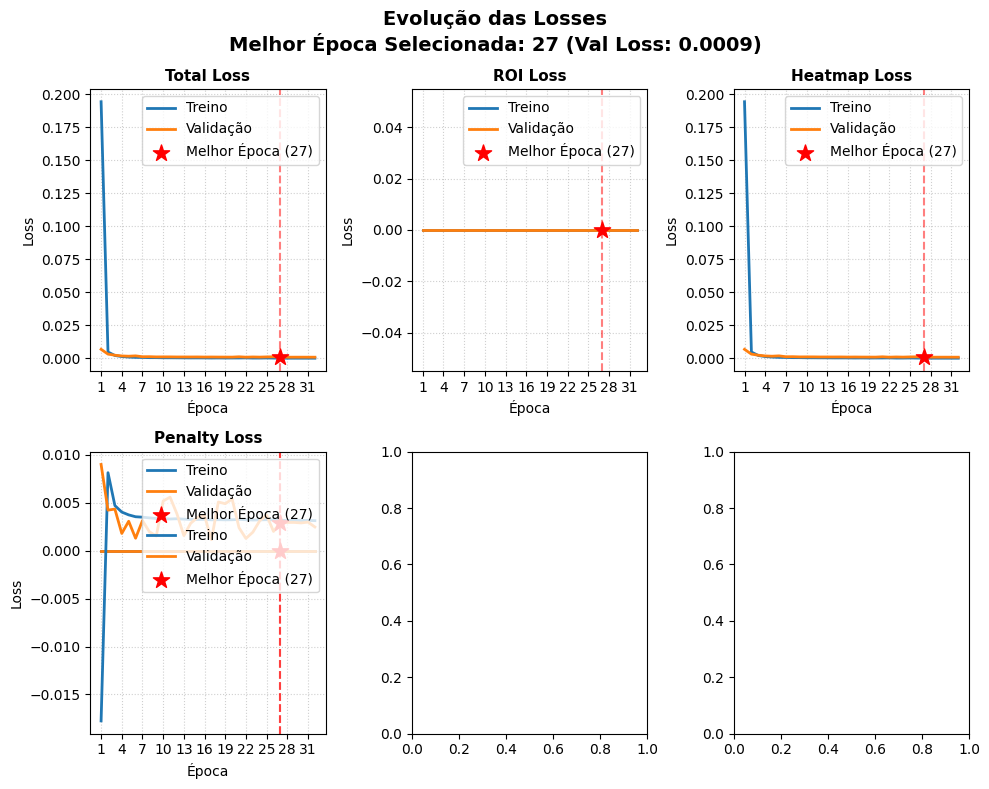

✓ Gráfico salvo: loss_distributions.png


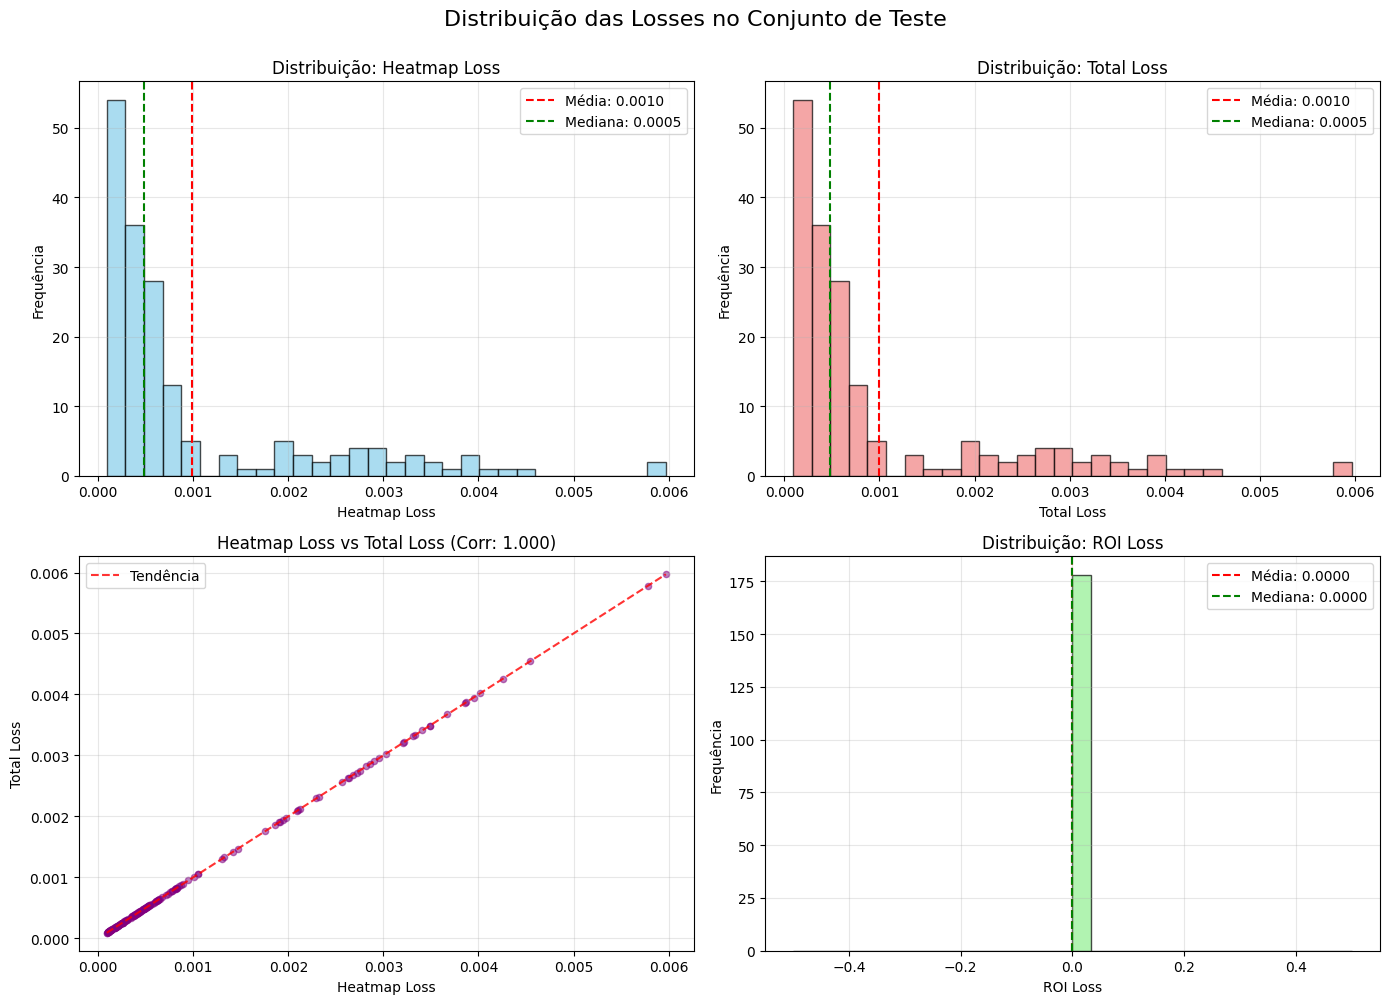

✓ Gráfico salvo: keypoint_analysis.png


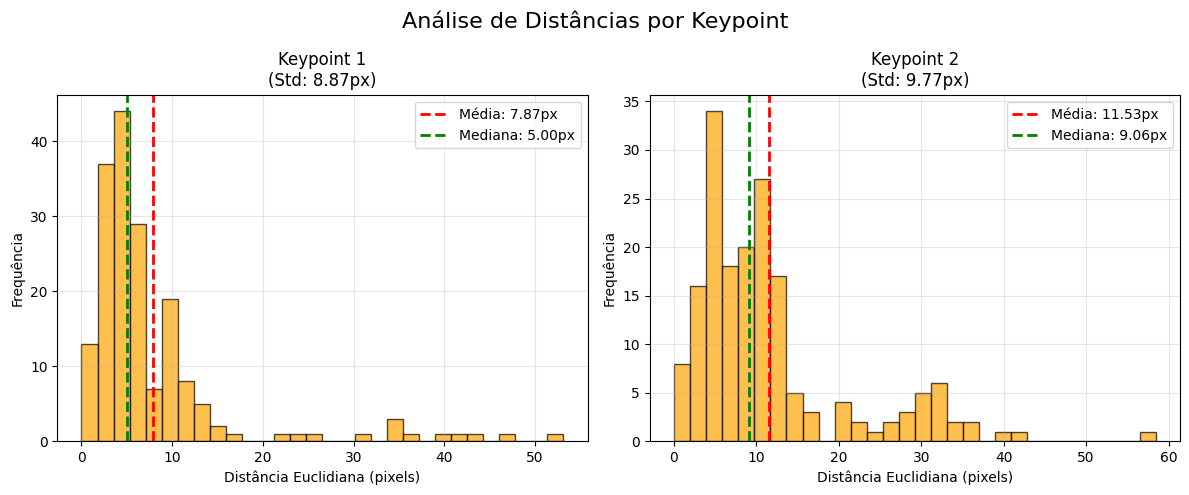


--- Visualizações para Keypoint 1 ---
✓ Figura salva: predictions_by_distance_keypoint1.png


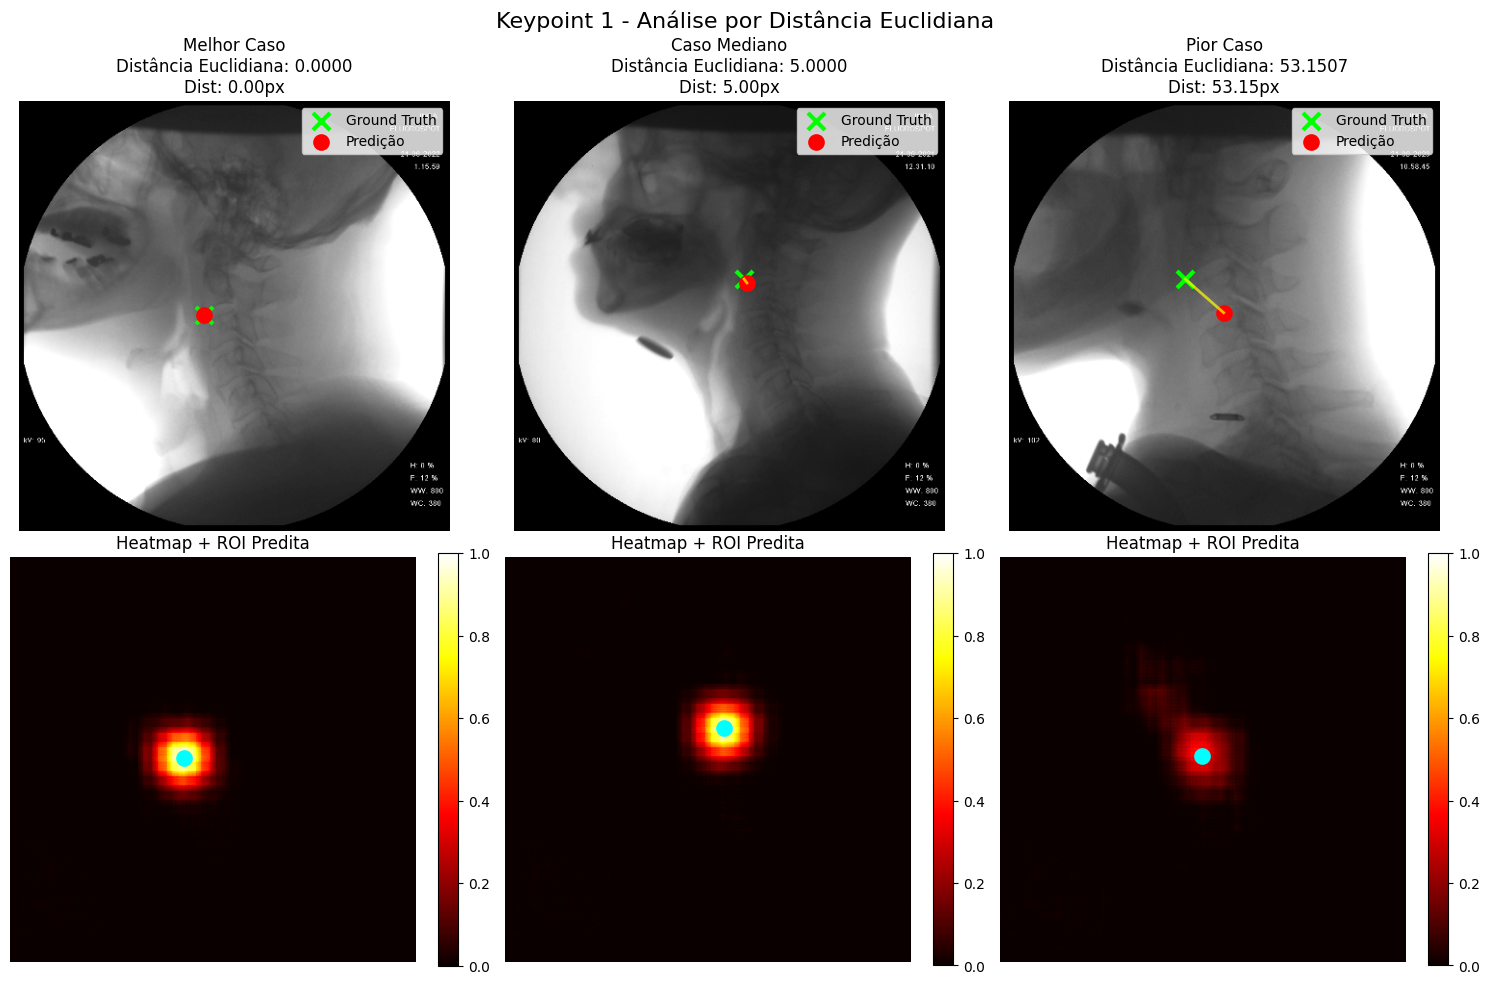


--- Visualizações para Keypoint 2 ---
✓ Figura salva: predictions_by_distance_keypoint2.png


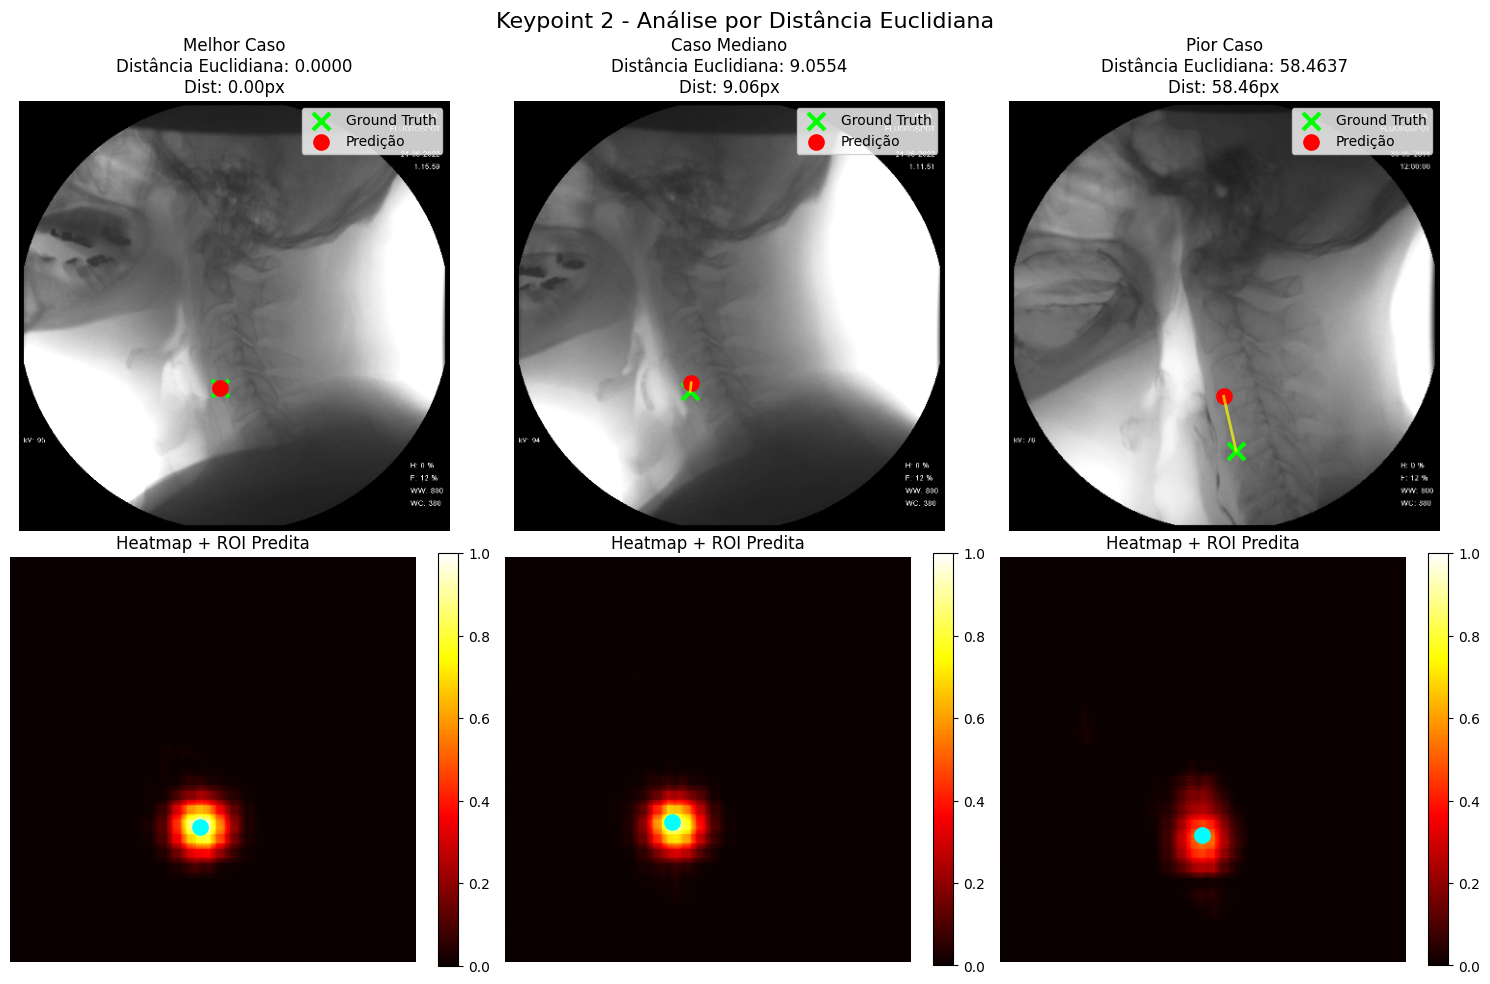


--- Visualizações para Keypoint 1 ---
✓ Figura salva: predictions_by_loss_keypoint1.png


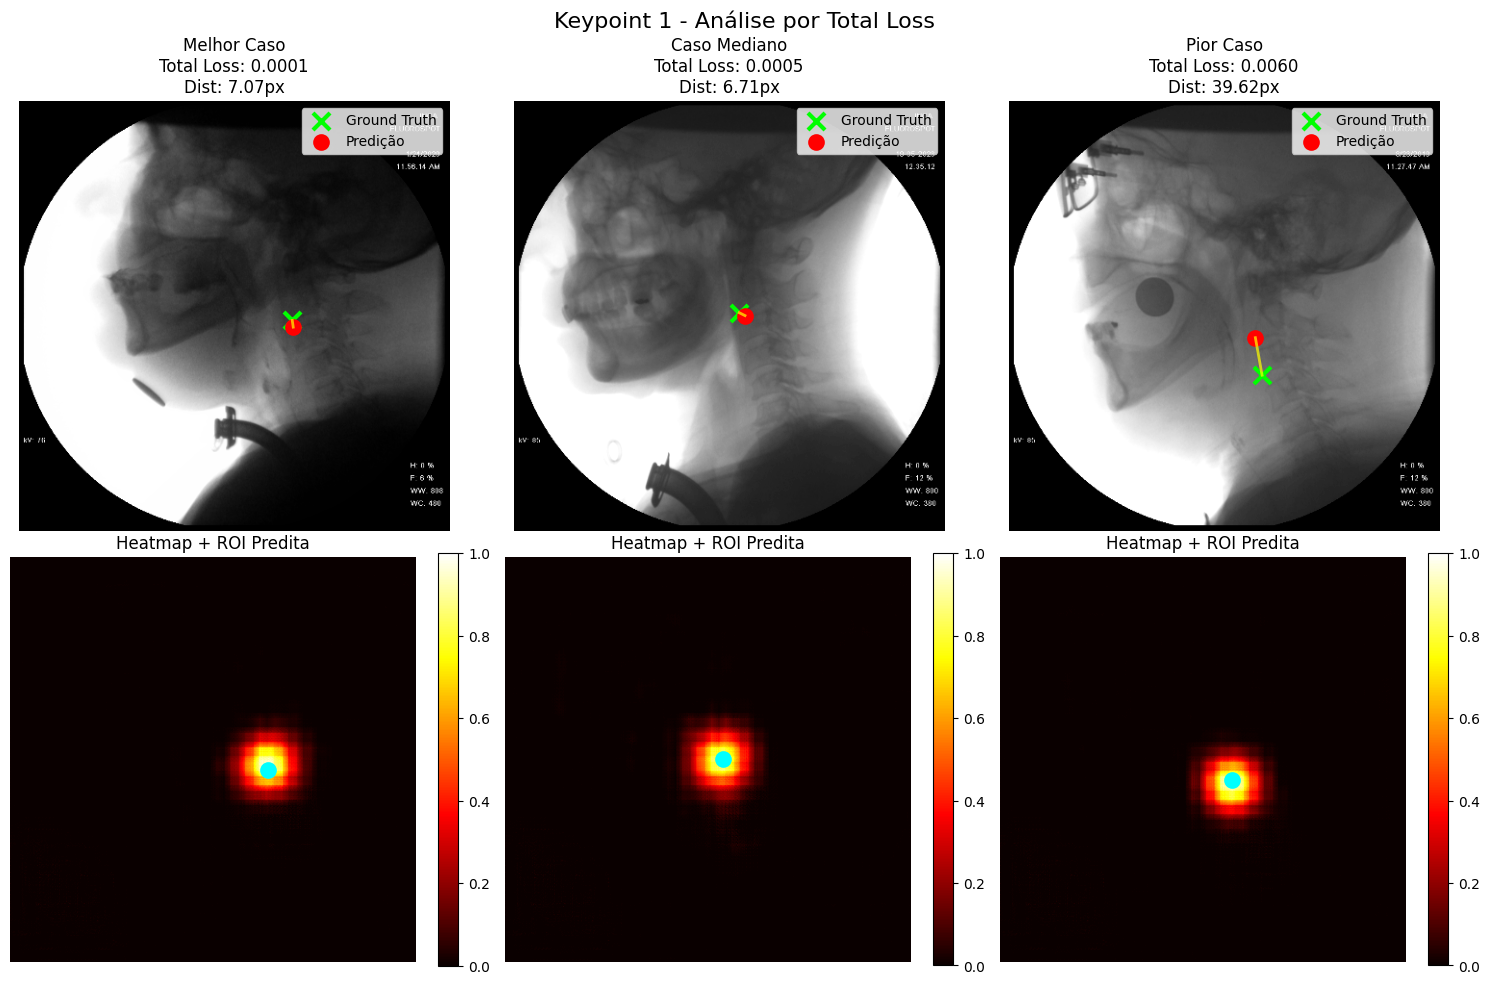


--- Visualizações para Keypoint 2 ---
✓ Figura salva: predictions_by_loss_keypoint2.png


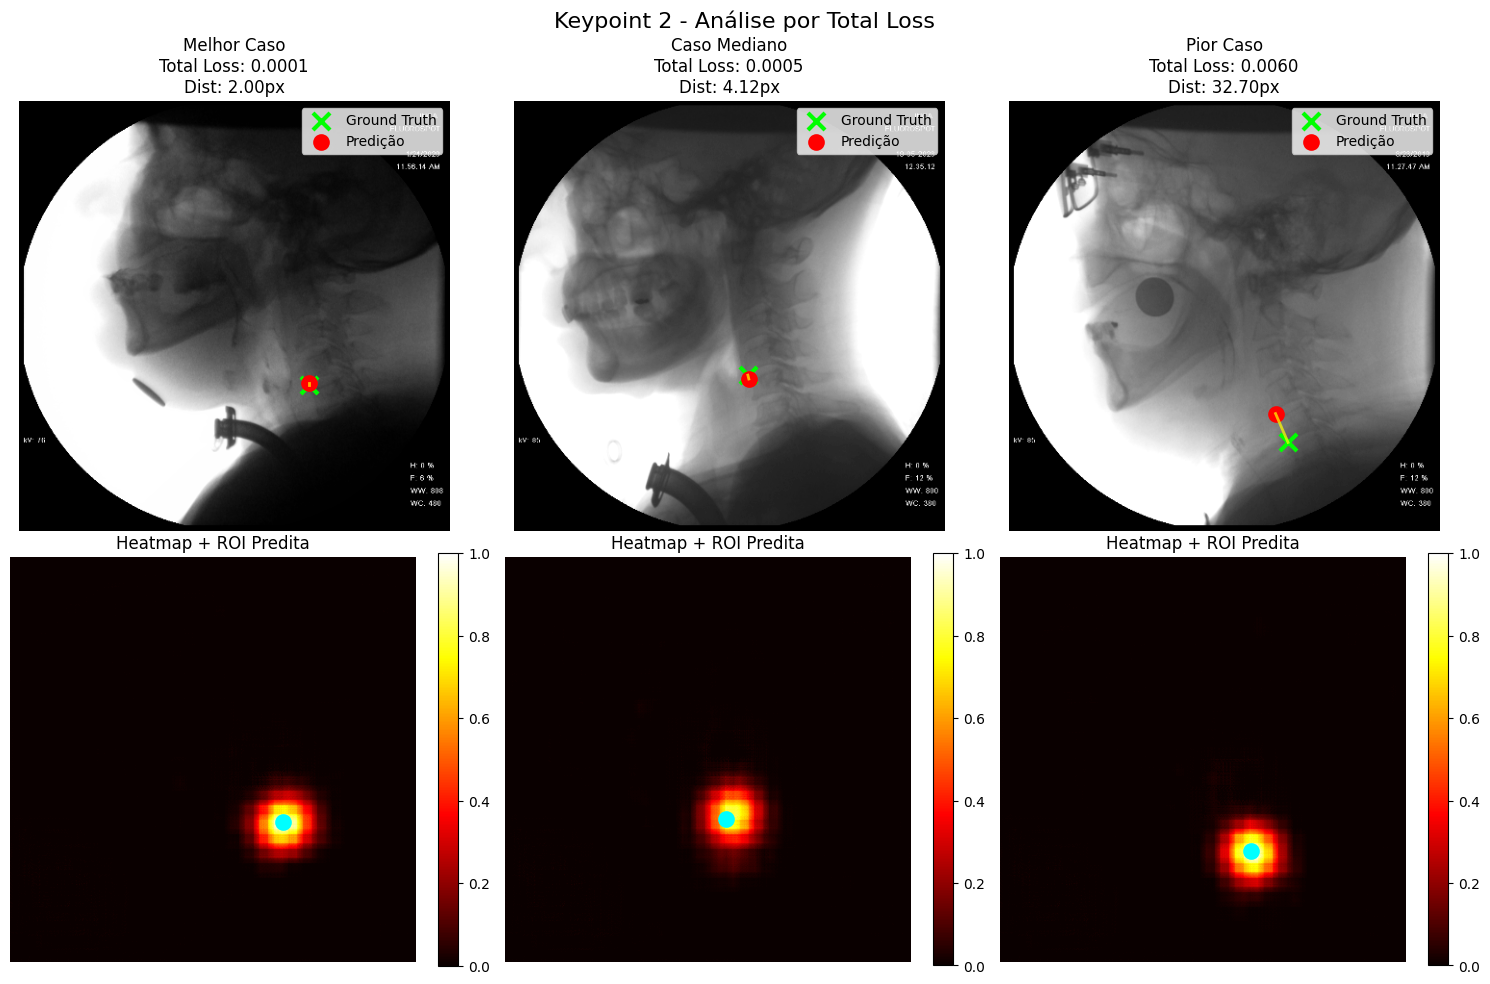

c:\Users\viniciuscosta\Documents\Projects\INCA\INF2008_code\.venv\lib\site-packages\scipy\stats\_stats_py.py:4424: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))


RELATÓRIO DE AVALIAÇÃO NO CONJUNTO DE TESTE

Número de amostras: 178

----------------------------------------------------------------------
LOSS TOTAL
----------------------------------------------------------------------
Média:    0.000992
Mediana:  0.000480
Std:      0.001195
Min:      0.000090
Max:      0.005971

----------------------------------------------------------------------
HEATMAP LOSS
----------------------------------------------------------------------
Média:    0.000992
Mediana:  0.000480
Std:      0.001195

----------------------------------------------------------------------
ROI LOSS
----------------------------------------------------------------------
Média:    0.000000
Mediana:  0.000000
Std:      0.000000

----------------------------------------------------------------------
KEYPOINT 1 - DISTÂNCIA EUCLIDIANA (pixels)
----------------------------------------------------------------------
Média:    7.87
Mediana:  5.00
Std:      8.87
Min:      0.00
Max:      53.1

Avaliando: 100%|██████████| 178/178 [00:14<00:00, 12.29it/s]


In [6]:
# Criando objeto de comparação
comp = ModelComparator(dict_config=dict_config)
dfMetrics = comp.calculate_metrics()

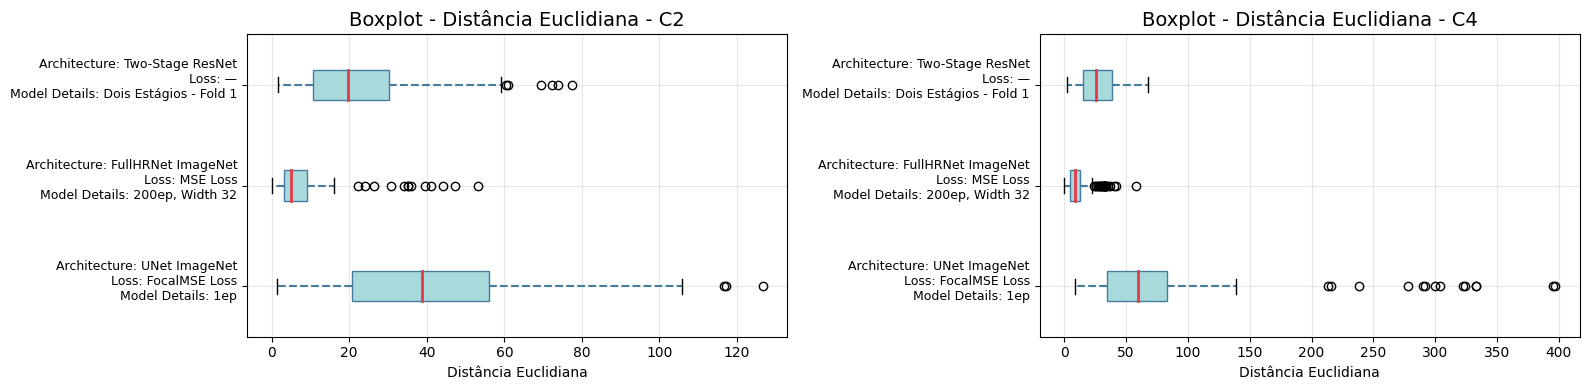

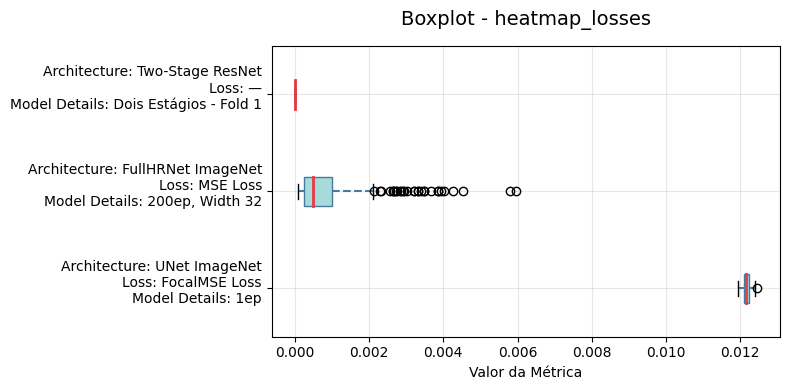

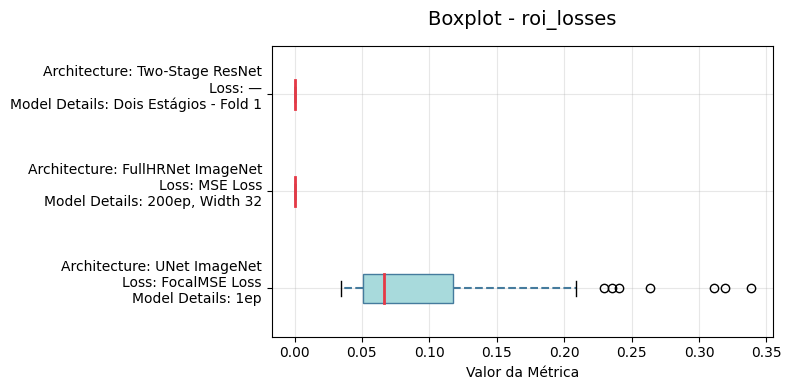

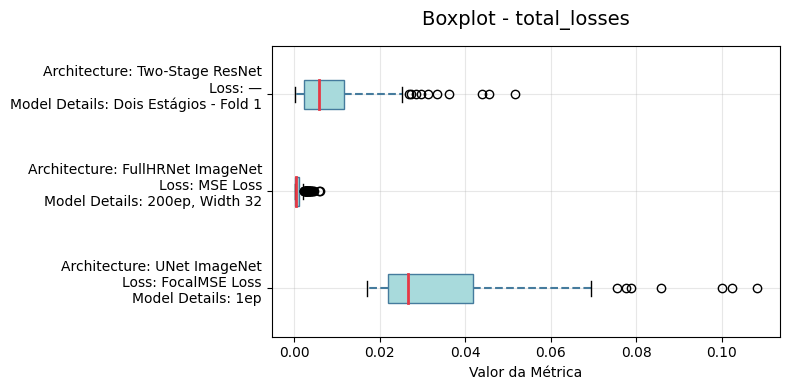

In [7]:
# Boxplot das Métricas
comp.plot_boxplot_metrics(["keypoint_distances", "heatmap_losses", "roi_losses", "total_losses"])

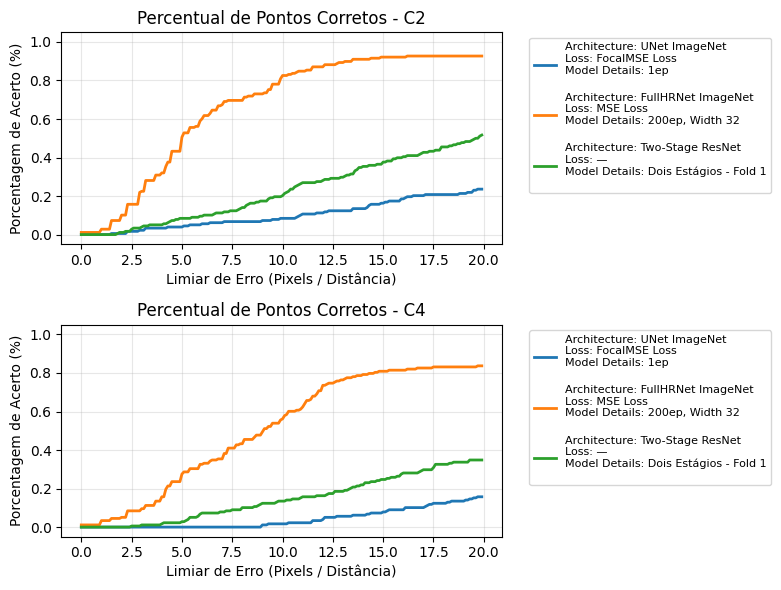

In [8]:
# Percentual de Pontos Corretos
comp.plot_percentage_correct_keypoint()